# VeriTriage — Data Exploration
## ML-Based Sign-Off Verification Triage for GPU Chip Physical Design

**Goal:** Understand all 5 datasets before building any ML model.

**Datasets:**
- IR Drop (10,242 samples) → verification target 1
- Cell Density (10,242 samples) → input feature
- Macro Region (10,242 samples) → input feature  
- DRC (10,242 samples) → verification target 2
- Congestion (20,484 samples) → verification target 3

In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(r"C:\Users\TUSHAR\2026-27\PROJECTS\VeriTriage")

PATHS = {
    "IR_drop":      ROOT / "data/raw/circuitnet/IR_drop/IR_drop",
    "cell_density": ROOT / "data/raw/circuitnet/routability/cell_density/cell_density",
    "macro_region": ROOT / "data/raw/circuitnet/routability/macro_region/macro_region",
    "DRC":          ROOT / "data/raw/circuitnet/routability/DRC/DRC_all",
    "congestion_h": ROOT / "data/raw/circuitnet/routability/congestion/overflow_based/congestion_eGR_horizontal_overflow",
    "congestion_v": ROOT / "data/raw/circuitnet/routability/congestion/overflow_based/congestion_eGR_vertical_overflow",
}

print("="*55)
print("  VeriTriage Dataset Inventory")
print("="*55)
for name, path in PATHS.items():
    if path.exists():
        files = list(path.iterdir())
        print(f"  {name:15s} → {len(files):6d} files  ✅")
    else:
        print(f"  {name:15s} → PATH NOT FOUND ❌")
print("="*55)

  VeriTriage Dataset Inventory
  IR_drop         →  10242 files  ✅
  cell_density    →  10242 files  ✅
  macro_region    →  10242 files  ✅
  DRC             →  10242 files  ✅
  congestion_h    →  10242 files  ✅
  congestion_v    →  10242 files  ✅


In [4]:
# Load one sample from each dataset and inspect
print("="*55)
print("  Sample Inspection")
print("="*55)

for name, path in PATHS.items():
    files = sorted(path.iterdir())
    sample = np.load(files[0])
    print(f"\n  {name}")
    print(f"    File:  {files[0].name}")
    print(f"    Shape: {sample.shape}")
    print(f"    Dtype: {sample.dtype}")
    print(f"    Min:   {sample.min():.4f}")
    print(f"    Max:   {sample.max():.4f}")
    print(f"    Mean:  {sample.mean():.4f}")

print("\n" + "="*55)

  Sample Inspection

  IR_drop
    File:  1-RISCY-a-1-c2-u0.7-m1-p1-f0
    Shape: (259, 259)
    Dtype: float64
    Min:   0.0000
    Max:   4.8339
    Mean:  0.2129

  cell_density
    File:  1-RISCY-a-1-c2-u0.7-m1-p1-f0
    Shape: (259, 259)
    Dtype: float64
    Min:   0.0000
    Max:   9.0000
    Mean:  1.2014

  macro_region
    File:  1-RISCY-a-1-c2-u0.7-m1-p1-f0
    Shape: (259, 259)
    Dtype: float64
    Min:   0.0000
    Max:   1.0000
    Mean:  0.3832

  DRC
    File:  1-RISCY-a-1-c2-u0.7-m1-p1-f0
    Shape: (259, 259)
    Dtype: float64
    Min:   0.0000
    Max:   3.0000
    Mean:  0.0045

  congestion_h
    File:  1-RISCY-a-1-c2-u0.7-m1-p1-f0
    Shape: (278, 278)
    Dtype: int64
    Min:   0.0000
    Max:   0.0000
    Mean:  0.0000

  congestion_v
    File:  1-RISCY-a-1-c2-u0.7-m1-p1-f0
    Shape: (278, 278)
    Dtype: float64
    Min:   0.0000
    Max:   0.2000
    Mean:  0.0000



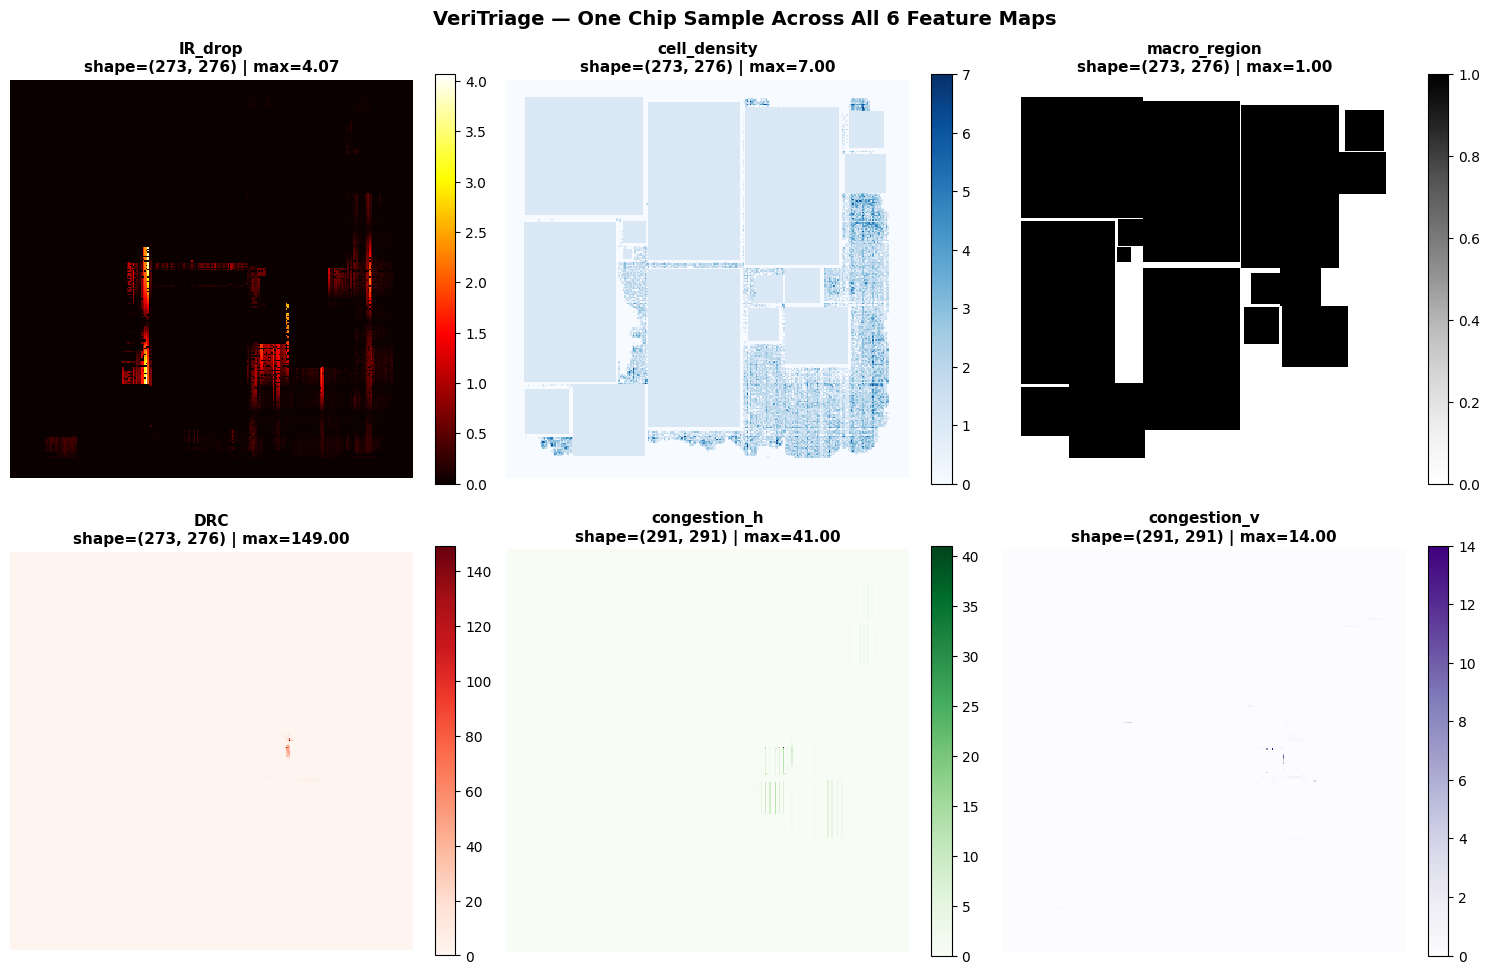

Plot saved!


In [5]:
# Visualize one sample from each dataset
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cmaps = {
    "IR_drop":      "hot",
    "cell_density": "Blues",
    "macro_region": "Greys",
    "DRC":          "Reds",
    "congestion_h": "Greens",
    "congestion_v": "Purples",
}

for idx, (name, path) in enumerate(PATHS.items()):
    files = sorted(path.iterdir())
    sample = np.load(files[100])  # sample 100
    im = axes[idx].imshow(sample, cmap=cmaps[name], interpolation='nearest')
    axes[idx].set_title(f"{name}\nshape={sample.shape} | max={sample.max():.2f}", 
                        fontsize=11, fontweight='bold')
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

plt.suptitle("VeriTriage — One Chip Sample Across All 6 Feature Maps", 
             fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = ROOT / "results" / "plots"
save_path.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path / "01_dataset_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [6]:
# Decode filename structure — this tells us CPU vs GPU vs AI chip
files = sorted(PATHS["IR_drop"].iterdir())

print("Sample filenames and what they mean:")
print("="*60)
for f in files[:10]:
    name = f.name
    parts = name.split('-')
    print(f"  {name}")

print("\n...")
print("\nUnique design types:")
designs = set()
for f in PATHS["IR_drop"].iterdir():
    parts = f.name.split('-')
    if len(parts) > 1:
        designs.add(parts[1])  # second part = design name

for d in sorted(designs):
    count = sum(1 for f in PATHS["IR_drop"].iterdir() 
                if f.name.split('-')[1] == d if len(f.name.split('-')) > 1)
    print(f"  {d:20s} → {count:5d} samples")


Sample filenames and what they mean:
  1-RISCY-a-1-c2-u0.7-m1-p1-f0
  10-RISCY-a-1-c2-u0.7-m2-p2-f0
  100-RISCY-a-1-c2-u0.85-m2-p3-f0
  1000-RISCY-a-2-c5-u0.75-m2-p1-f0
  10000-zero-riscy-b-3-c2-u0.85-m1-p6-f1
  10001-zero-riscy-b-3-c2-u0.85-m1-p7-f1
  10002-zero-riscy-b-3-c2-u0.85-m1-p8-f1
  10003-zero-riscy-b-3-c2-u0.85-m2-p3-f1
  10004-zero-riscy-b-3-c2-u0.85-m2-p4-f1
  10005-zero-riscy-b-3-c2-u0.85-m2-p5-f1

...

Unique design types:
  RISCY                →  7078 samples
  zero                 →  3164 samples


In [7]:
import re
configs = []
for f in PATHS["IR_drop"].iterdir():
    parts = f.name.split('-')
    if len(parts) >= 7:
        configs.append({
            'name':      f.name,
            'design':    parts[1] if len(parts) > 1 else '?',
            'variant':   parts[2] if len(parts) > 2 else '?',
            'freq':      parts[3] if len(parts) > 3 else '?',
            'util':      parts[4] if len(parts) > 4 else '?',
            'macro':     parts[5] if len(parts) > 5 else '?',
            'placement': parts[6] if len(parts) > 6 else '?',
        })

import pandas as pd
df = pd.DataFrame(configs)
print(f"Total samples: {len(df)}")
print(f"\nDesign types:\n{df['design'].value_counts()}")
print(f"\nVariants:\n{df['variant'].value_counts()}")
print(f"\nUtilization values:\n{df['util'].value_counts().sort_index()}")
print(f"\nMacro configs:\n{df['macro'].value_counts().sort_index()}")

Total samples: 10242

Design types:
design
RISCY    7078
zero     3164
Name: count, dtype: int64

Variants:
variant
FPU      3217
riscy    3164
a        2003
b        1858
Name: count, dtype: int64

Utilization values:
util
1      2445
2      1806
3      2130
c2     1335
c20    1130
c5     1396
Name: count, dtype: int64

Macro configs:
macro
c2       1915
c20      1690
c5       2776
u0.7      870
u0.75     867
u0.8      831
u0.85     731
u0.9      562
Name: count, dtype: int64
